# AI Impact on Jobs: Predicting AI-Driven Layoff Risk

**Dataset:** [AI Impact on Jobs and Layoff Risk Dataset](https://www.kaggle.com/datasets/shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset/data)  


---
## 1. Dependencies

In [69]:
import warnings
warnings.filterwarnings('ignore') # suppress non-critical sklearn/pandas warnings for cleaner notebook output

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42

# Consistent plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'cmr10'

## 2. Load & Inspect Data

In [70]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

DATASET_HANDLE = (
    "shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset"
)
FILE_PATH = "ai-impact-jobs-layoff-risk-dataset.csv"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET_HANDLE,
    FILE_PATH,
)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Using Colab cache for faster access to the 'ai-impact-on-jobs-and-layoff-risk-dataset' dataset.
Dataset loaded: 20,000 rows × 16 columns


### Basic dataset investigations

In [71]:
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

In [73]:
df.describe()

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


### Check for missing values

In [74]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing >= 0].to_string())
print(f'\nTotal missing cells: {missing.sum()}')

Missing values per column:
Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0

Total missing cells: 0


### Check for duplicate rows

In [75]:
n_duplicates = df.duplicated().sum()
print(f'Duplicate rows: {n_duplicates}')

Duplicate rows: 0


### Categorical features and their unique values

In [76]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns and their unique values:')
for col in categorical_cols:
    print(f'  {col}: {sorted(df[col].unique().tolist())}')

Categorical columns and their unique values:
  Education_Level: ["Bachelor's", 'High School', "Master's", 'PhD']
  Industry: ['Education', 'Finance', 'Healthcare', 'IT', 'Logistics', 'Manufacturing', 'Retail', 'Telecom']
  Job_Role: ['Academic Coordinator', 'Accountant', 'Auditor', 'Data Analyst', 'Dispatcher', 'Financial Analyst', 'Health Analyst', 'Inventory Analyst', 'ML Engineer', 'Medical Assistant', 'Network Engineer', 'Nurse', 'Operations Analyst', 'Operator', 'Production Supervisor', 'Quality Engineer', 'Research Assistant', 'Sales Associate', 'Software Engineer', 'Store Manager', 'Supply Chain Analyst', 'Support Specialist', 'Teacher', 'Warehouse Manager']
  Company_Size: ['Large', 'Medium', 'Small']
  Job_Level: ['Entry', 'Mid', 'Senior']
  AI_Adoption_Level: ['High', 'Low', 'Medium']
  Layoff_Risk: ['High', 'Low', 'Medium']


## 3. Exploratory Data Analysis


### Target class distribution

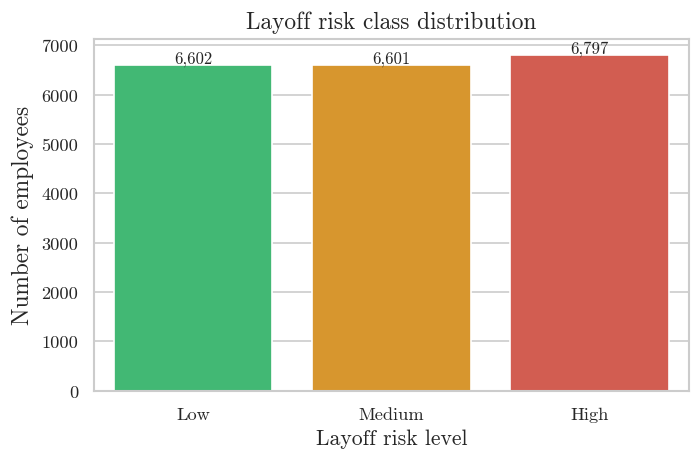

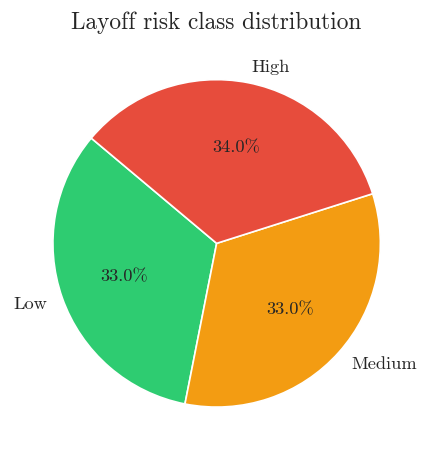

In [77]:
"""
Class balance check for the target variable.
This matters because class imbalance affects model choice, evaluation metric selection (accuracy vs. F1), and whether resampling/class
weighting will be needed before training.
"""

order = ['Low', 'Medium', 'High']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Layoff_Risk', order=order, palette=colors)
plt.title('Layoff risk class distribution', fontsize=14)
plt.xlabel('Layoff risk level', fontsize=13)
plt.ylabel('Number of employees', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 50),
                ha='center', fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
counts = df['Layoff_Risk'].value_counts().reindex(order)
plt.pie(counts, labels=order, autopct='%1.1f%%',
        colors=colors, startangle=140, textprops={'fontsize': 11})
plt.title('Layoff risk class distribution', fontsize=14)
plt.tight_layout()
plt.show()

### Feature Distributions

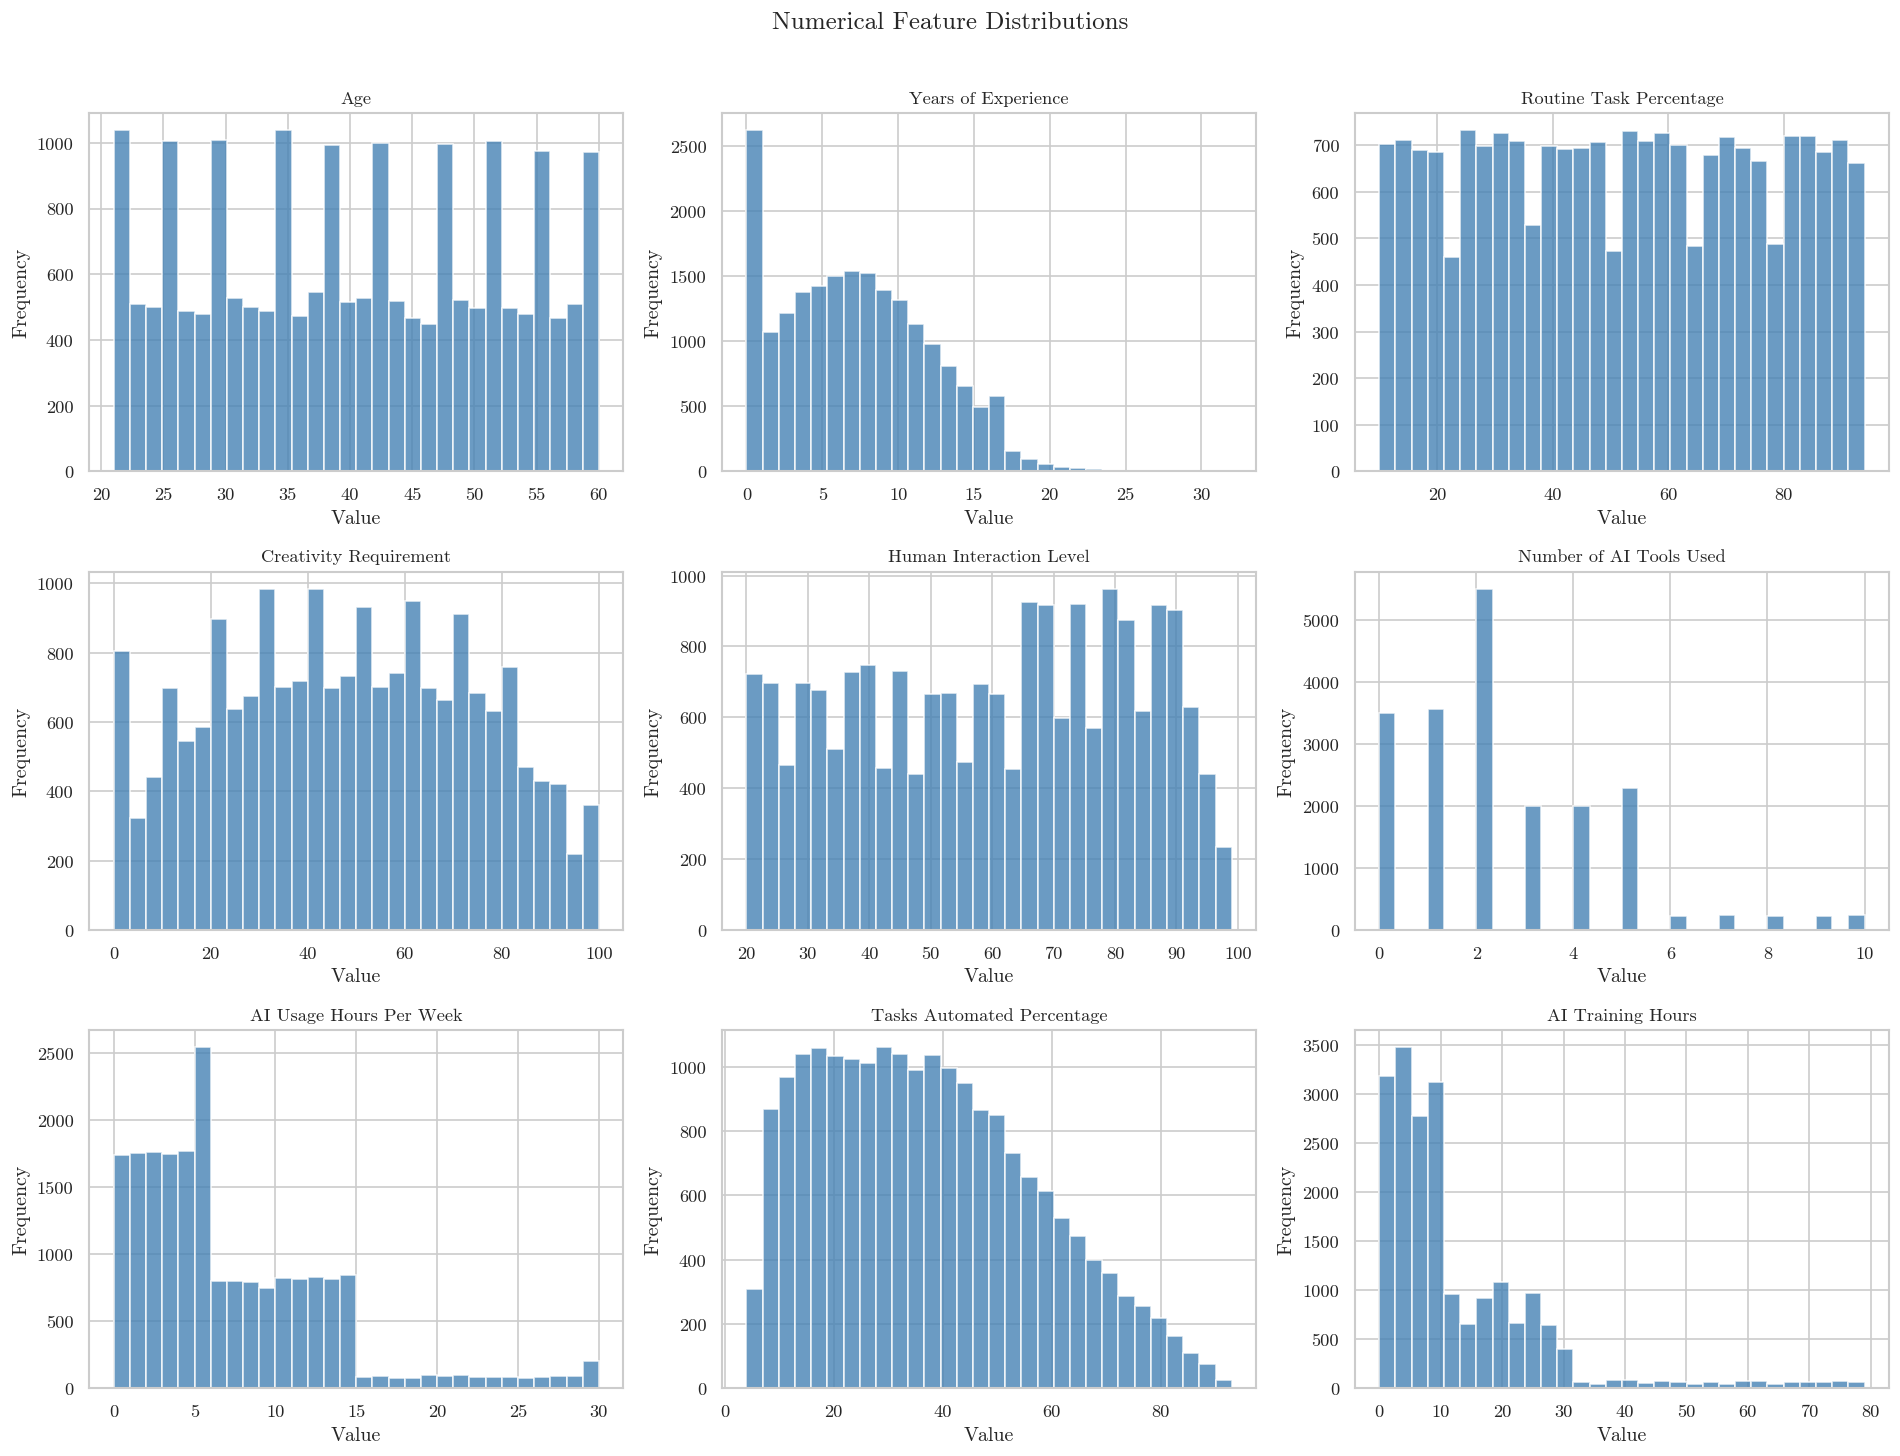

In [78]:
"""
Univariate distribution check for all numerical features.
Purpose: spot skewness, outliers, and scale differences up front. This directly informs later choices like StandardScaler vs. robust scaling.
"""

numerical_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' '), fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### Layoff Risk Distribution by Industry

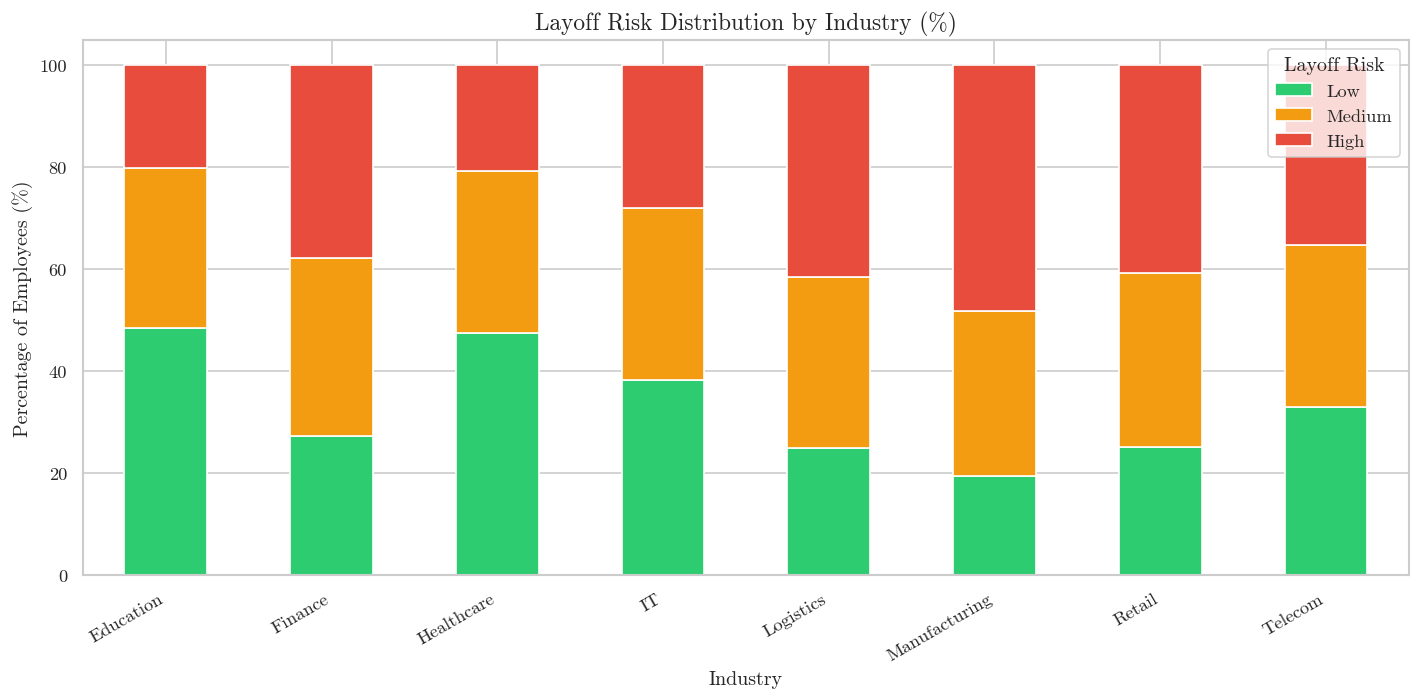

In [79]:
industry_risk = (df.groupby(['Industry', 'Layoff_Risk'])
                   .size()
                   .unstack(fill_value=0)
                   .reindex(columns=order))

industry_risk_pct = industry_risk.div(industry_risk.sum(axis=1), axis=0) * 100

ax = industry_risk_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
                             color=['#2ecc71', '#f39c12', '#e74c3c'],
                             edgecolor='white')
ax.set_title('Layoff Risk Distribution by Industry (%)', fontsize=14)
ax.set_xlabel('Industry')
ax.set_ylabel('Percentage of Employees (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Layoff Risk', labels=order, loc='upper right')
plt.tight_layout()
plt.show()

### Feature Visualizations by Layoff Risk

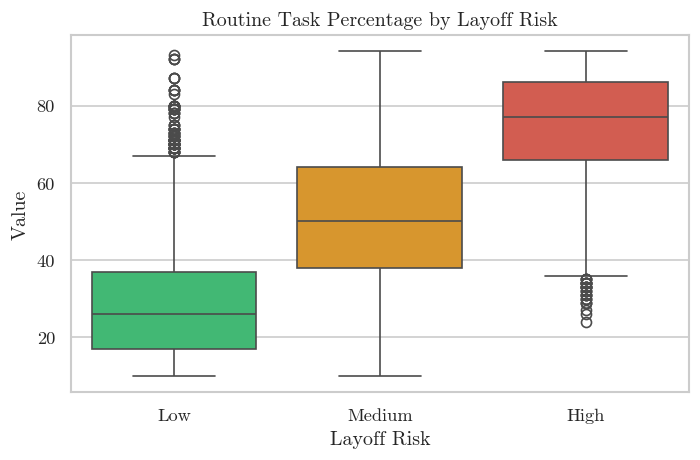

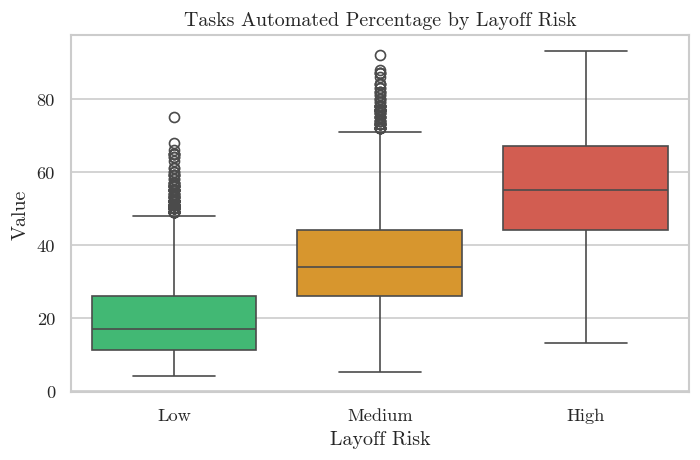

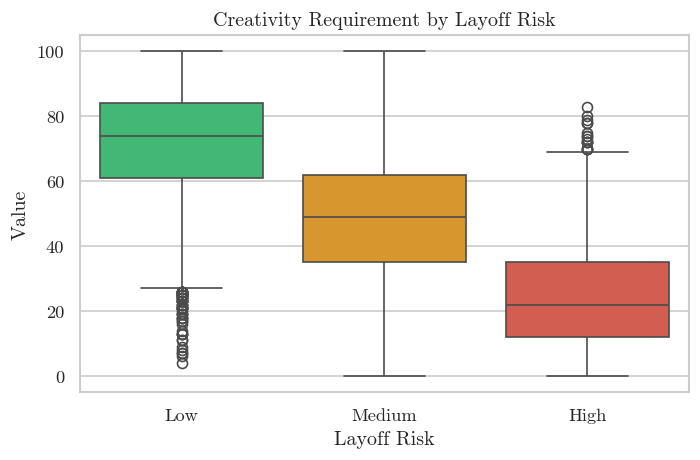

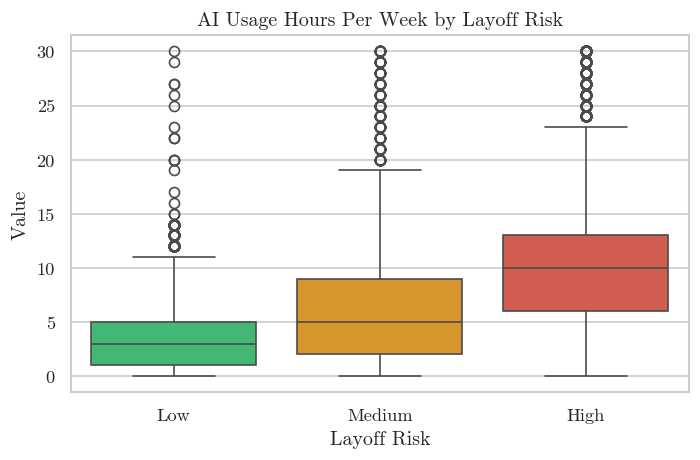

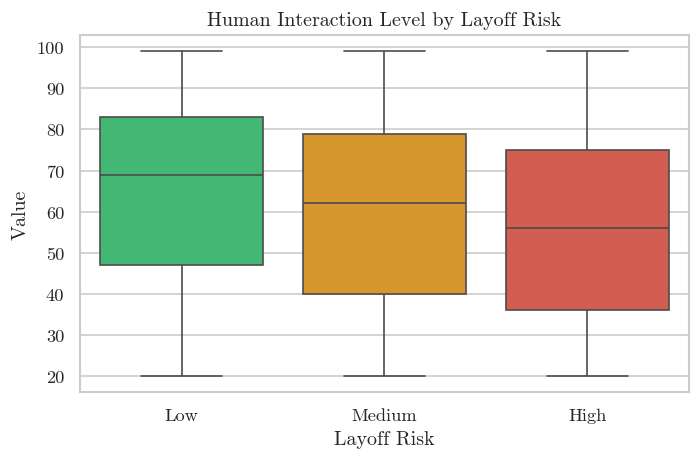

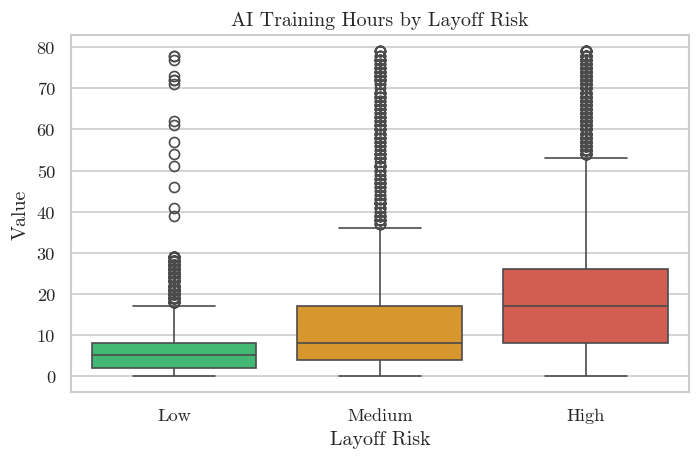

In [80]:
key_features = ['Routine_Task_Percentage', 'Tasks_Automated_Percentage',
                'Creativity_Requirement', 'AI_Usage_Hours_Per_Week',
                'Human_Interaction_Level', 'AI_Training_Hours']

order = ['Low', 'Medium', 'High']
palette = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for col in key_features:
    plt.figure(figsize=(6, 4))

    sns.boxplot(data=df, x='Layoff_Risk', y=col, order=order, palette=palette)

    plt.title(f"{col.replace('_', ' ')} by Layoff Risk", fontsize=12)
    plt.xlabel('Layoff Risk')
    plt.ylabel('Value')

    plt.tight_layout()
    plt.show()

### Layoff Risk by AI Adoption Level

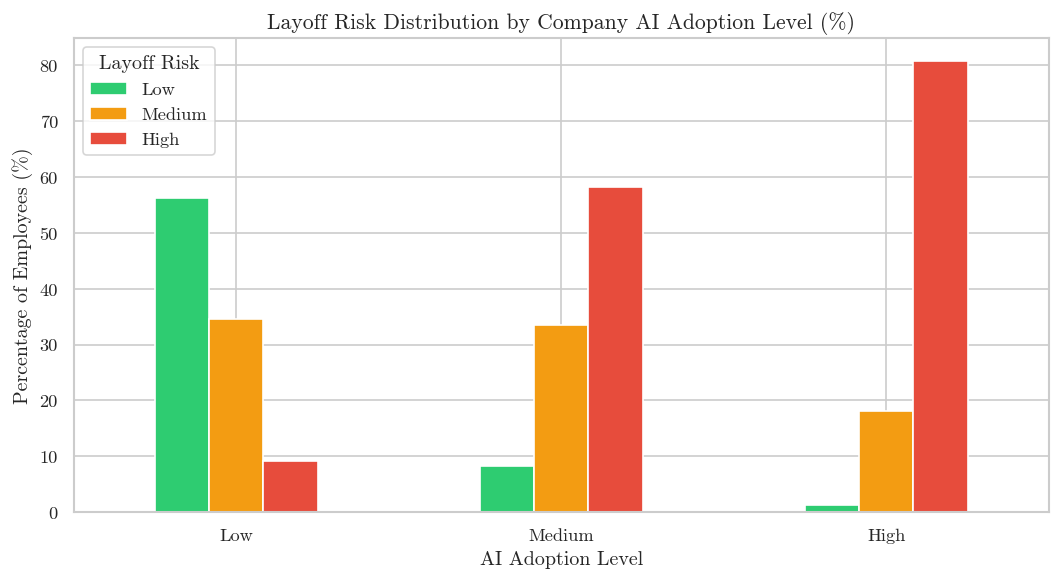

In [81]:
adoption_risk = (df.groupby(['AI_Adoption_Level', 'Layoff_Risk'])
                   .size()
                   .unstack(fill_value=0)
                   .reindex(index=['Low', 'Medium', 'High'],
                            columns=order))

adoption_risk_pct = adoption_risk.div(adoption_risk.sum(axis=1), axis=0) * 100

ax = adoption_risk_pct.plot(kind='bar', figsize=(9, 5),
                             color=['#2ecc71', '#f39c12', '#e74c3c'],
                             edgecolor='white')
ax.set_title('Layoff Risk Distribution by Company AI Adoption Level (%)', fontsize=13)
ax.set_xlabel('AI Adoption Level')
ax.set_ylabel('Percentage of Employees (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Layoff Risk', labels=order)
plt.tight_layout()
plt.show()

## 4. Preprocessing

### Encoding Ordinal Categorical Features

In [82]:
"""
Ordinal encoding for categorical features that have a natural order.
A new df_processed is created (rather than overwriting df) to keep the
raw dataset intact for reference/EDA. This means downstream cells
must explicitly use df_processed to see these changes.
"""

df_processed = df.copy()

education_order = {'High School': 0, "Bachelor's": 1, "Master's": 2, 'PhD': 3}
df_processed['Education_Level'] = df_processed['Education_Level'].map(education_order)

job_level_order = {'Entry': 0, 'Mid': 1, 'Senior': 2}
df_processed['Job_Level'] = df_processed['Job_Level'].map(job_level_order)

company_size_order = {'Small': 0, 'Medium': 1, 'Large': 2}
df_processed['Company_Size'] = df_processed['Company_Size'].map(company_size_order)

ai_adoption_order = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['AI_Adoption_Level'] = df_processed['AI_Adoption_Level'].map(ai_adoption_order)

print('Ordinal encoding complete.')
df_processed[['Education_Level', 'Job_Level', 'Company_Size', 'AI_Adoption_Level']].head(3)

Ordinal encoding complete.


,Education_Level,Job_Level,Company_Size,AI_Adoption_Level
0,2,0,1,1
1,2,0,0,0
2,1,2,1,0


### One-Hot Encoding of Nominal Categorical Features

In [83]:
"""
One-hot encode nominal features (Industry, Job_Role) since they have
no natural order. drop_first=True avoids the dummy variable trap.
"""

df_processed = pd.get_dummies(df_processed,
                               columns=['Industry', 'Job_Role'],
                               drop_first=True)

print(f'Shape after one-hot encoding: {df_processed.shape}')

Shape after one-hot encoding: (20000, 44)


### Ordinal Encoding of Target Variable

In [84]:
"""
Encode target as ordinal integers (Low < Medium < High) to preserve
its natural ordering for modeling and correlation analysis.
"""

target_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_processed['Layoff_Risk'] = df_processed['Layoff_Risk'].map(target_map)

print('Target encoding:', target_map)
print('Target value counts after encoding:')
print(df_processed['Layoff_Risk'].value_counts().sort_index())

Target encoding: {'Low': 0, 'Medium': 1, 'High': 2}
Target value counts after encoding:
Layoff_Risk
0    6602
1    6601
2    6797
Name: count, dtype: int64


### Splitting Input and Target Features

In [85]:
X = df_processed.drop(columns=['Layoff_Risk'])
y = df_processed['Layoff_Risk']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector  y: {y.shape}')

Feature matrix X: (20000, 43)
Target vector  y: (20000,)


### Correlation Heatmap

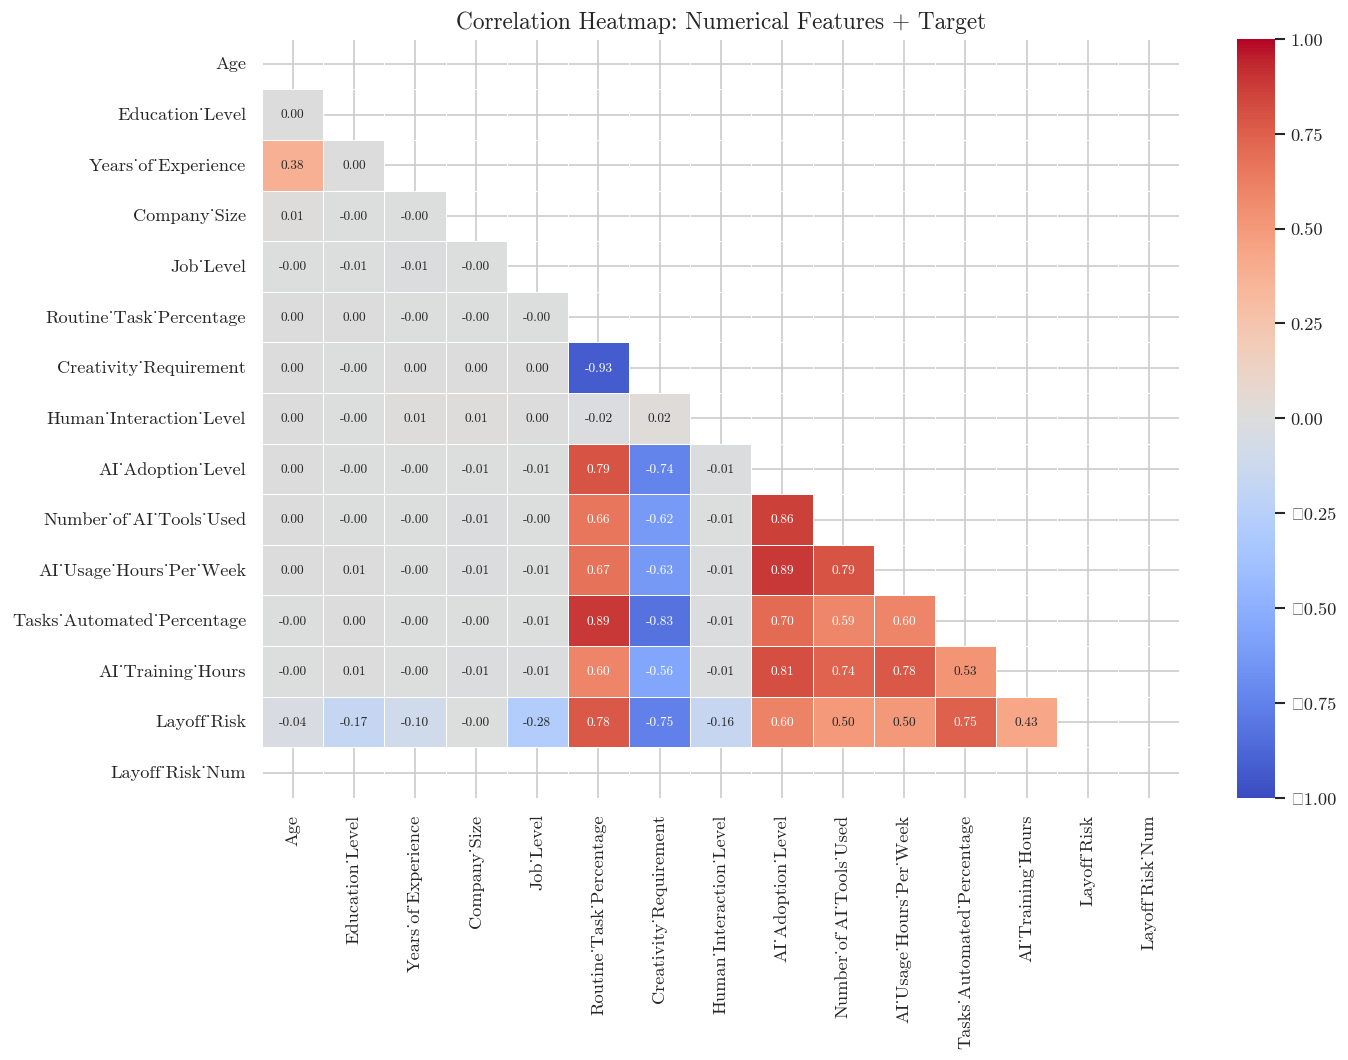

In [86]:
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}

numerical_cols_processed = df_processed.select_dtypes(include='number').columns.tolist()
corr_df = df_processed[numerical_cols_processed].copy()
corr_df['Layoff_Risk_Num'] = df_processed['Layoff_Risk'].map(risk_map)

corr_matrix = corr_df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('Correlation Heatmap: Numerical Features + Target', fontsize=14)
plt.tight_layout()
plt.show()

### Train-test Split

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training set  : {X_train.shape[0]:,} samples')
print(f'Test set      : {X_test.shape[0]:,} samples')
print(f'\nClass balance in training set:')
print(y_train.value_counts().sort_index())

Training set  : 16,000 samples
Test set      : 4,000 samples

Class balance in training set:
Layoff_Risk
0    5282
1    5281
2    5437
Name: count, dtype: int64


### Feature Scaling

In [88]:
"""
Fit scaler on train only, then apply to test — prevents test set
info from leaking into the scaling parameters.
"""

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Feature scaling complete (StandardScaler).')
print(f'Post-scaling — Train mean ≈ {X_train_scaled.mean():.4f}, std ≈ {X_train_scaled.std():.4f}')

Feature scaling complete (StandardScaler).
Post-scaling — Train mean ≈ -0.0000, std ≈ 1.0000


---
## 5. Model Building


### Logistic Regression Model

In [89]:
"""
lbfgs handles multiclass natively (softmax) and converges well on
scaled data. The higher max_iter is a safety margin.
"""

lr_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM_STATE
)

lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression — Test Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)')

# Generalisation test
train_acc_lr = lr_model.score(X_train_scaled, y_train)
print(f'Logistic Regression — Train: {train_acc_lr:.4f}, Test: {lr_accuracy:.4f}, Gap: {train_acc_lr - lr_accuracy:.4f}')


Logistic Regression — Test Accuracy: 0.9293 (92.92%)
Logistic Regression — Train: 0.9326, Test: 0.9293, Gap: 0.0033


### Random Forest Model

In [90]:
"""
n_jobs=-1 parallelizes across all CPU cores for faster training.
Scaling isn't required for random forest model, but reusing the
already-scaled data here is harmless.
"""

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest, Test Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)')

Random Forest — Test Accuracy: 0.8828 (88.28%)


## 6. Hyperparameter Tuning — Random Forest


In [91]:
"""
Grid search over key RF hyperparameters using 5-fold CV.
f1_weighted is used instead of accuracy since it accounts for
class imbalance across Low/Medium/High risk categories.
"""

param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [None, 20, 30],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid = param_grid,
    scoring    = 'f1_weighted',
    cv         = 5,
    verbose    = 1,
    n_jobs     = -1
)

grid_search.fit(X_train_scaled, y_train)

print(f'\nBest hyperparameters found: {grid_search.best_params_}')
print(f'Best cross-validated F1 (weighted): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best hyperparameters found: {'max_depth': 30, 'min_samples_leaf': 1, 'n_estimators': 200}
Best cross-validated F1 (weighted): 0.8872


### Evaluating the tuned model on the test set

In [92]:
"""
Evaluate the tuned model (best_estimator_) on held-out test data. This is the actual unbiased performance estimate, since CV scores
during grid search were only used to select hyperparameters.
"""

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

best_rf_accuracy = accuracy_score(y_test, y_pred_best)
print(f'Tuned Random Forest \n Test Accuracy: {best_rf_accuracy:.4f} ({best_rf_accuracy*100:.2f}%)\n')

# Generalisation test
train_acc_rf = best_rf.score(X_train_scaled, y_train)
print(f'Random Forest (Tuned); \n Train Accuracy: {train_acc_rf:.4f} versus Test Accuracy: {best_rf_accuracy:.4f}, Gap: {train_acc_rf - best_rf_accuracy:.4f}')

Tuned Random Forest 
 Test Accuracy: 0.8832 (88.33%)

Random Forest (Tuned); 
 Train Accuracy: 1.0000 versus Test Accuracy: 0.8832, Gap: 0.1168


## 7. Model Evaluation


### Classification Reports

In [93]:
class_names = ['Low', 'Medium', 'High']

print("CLASSIFICATION REPORTS \n")

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

print("\nRandom Forest (Tuned):")
print(classification_report(y_test, y_pred_best, target_names=class_names))

CLASSIFICATION REPORTS 

Logistic Regression:
              precision    recall  f1-score   support

         Low       0.94      0.95      0.94      1320
      Medium       0.90      0.89      0.89      1320
        High       0.95      0.95      0.95      1360

    accuracy                           0.93      4000
   macro avg       0.93      0.93      0.93      4000
weighted avg       0.93      0.93      0.93      4000


Random Forest (Tuned):
              precision    recall  f1-score   support

         Low       0.92      0.91      0.91      1320
      Medium       0.82      0.82      0.82      1320
        High       0.91      0.92      0.91      1360

    accuracy                           0.88      4000
   macro avg       0.88      0.88      0.88      4000
weighted avg       0.88      0.88      0.88      4000



### Confusion matrices

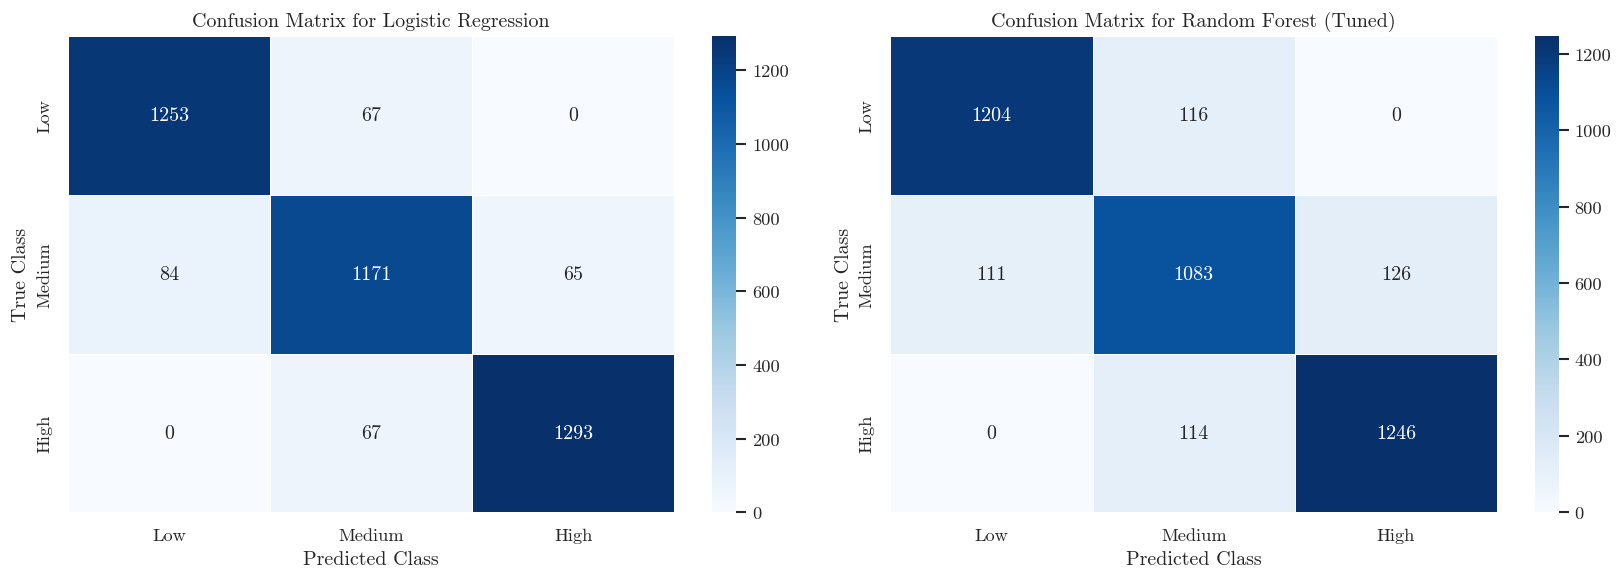

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_lr, y_pred_best],
    ['Logistic Regression', 'Random Forest (Tuned)']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f'Confusion Matrix for {title}', fontsize=12)
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')

plt.tight_layout()
plt.show()

### 5-Fold Cross-Validation

In [95]:
"""
Independent 5-fold CV on both models for a fair comparison. The standard deviation shows how stable each model's performance is
across different data splits, not just a single test-set snapshot.
"""

cv_scores_rf = cross_val_score(
    best_rf, X_train_scaled, y_train,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

cv_scores_lr = cross_val_score(
    lr_model, X_train_scaled, y_train,
    cv=5, scoring='f1_weighted', n_jobs=-1
)

print("5-Fold Cross-Validation F1 (weighted):\n")
print(f"Random Forest: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}\n")
print(f"Logistic Regression: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")

5-Fold Cross-Validation F1 (weighted):

Random Forest: 0.8872 ± 0.0037

Logistic Regression: 0.9280 ± 0.0030


## 8. Feature Importance

### Random Forest model

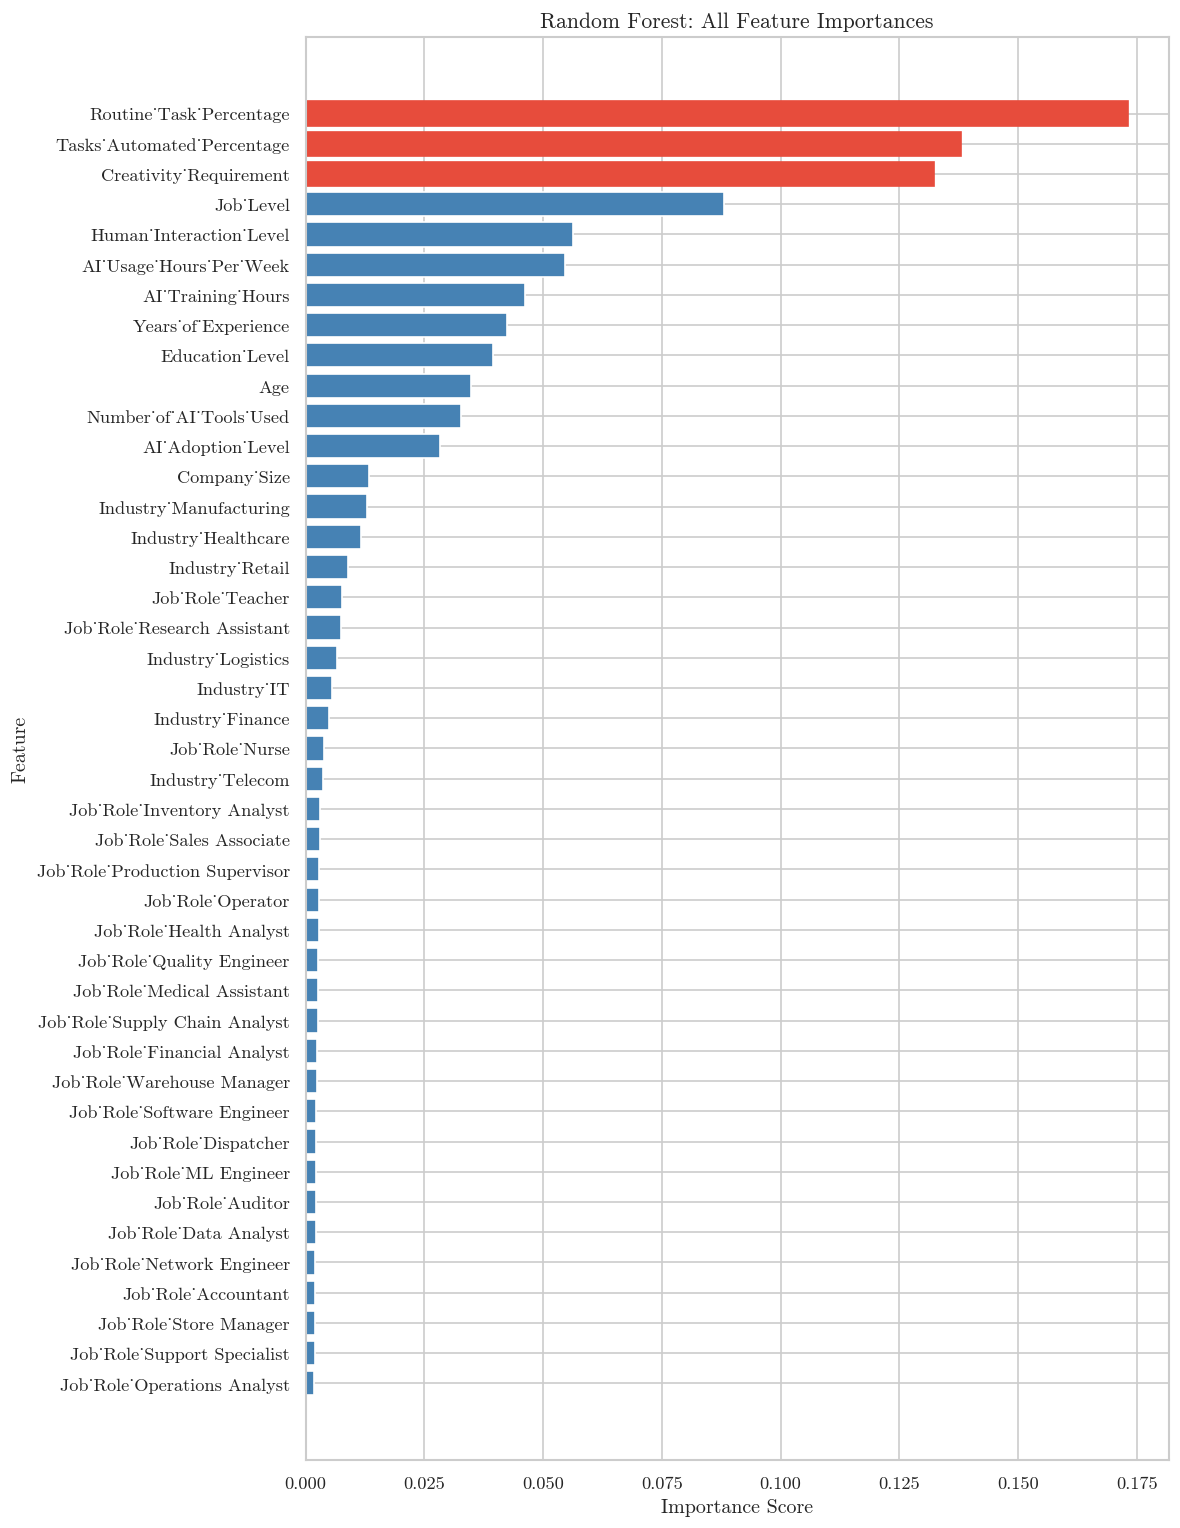

In [96]:
"""
Feature importance from the tuned RF. It shows which predictors the
model actually relies on most.
"""

feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

num_features = len(importance_df)
fig_height = max(7, num_features * 0.3)

plt.figure(figsize=(10, fig_height))
bars = plt.barh(importance_df['Feature'][::-1],
                importance_df['Importance'][::-1],
                color='steelblue', edgecolor='white')

for bar in bars[-3:]:
    bar.set_color('#e74c3c')

plt.title('Random Forest: All Feature Importances', fontsize=13)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Logistic Regression Model

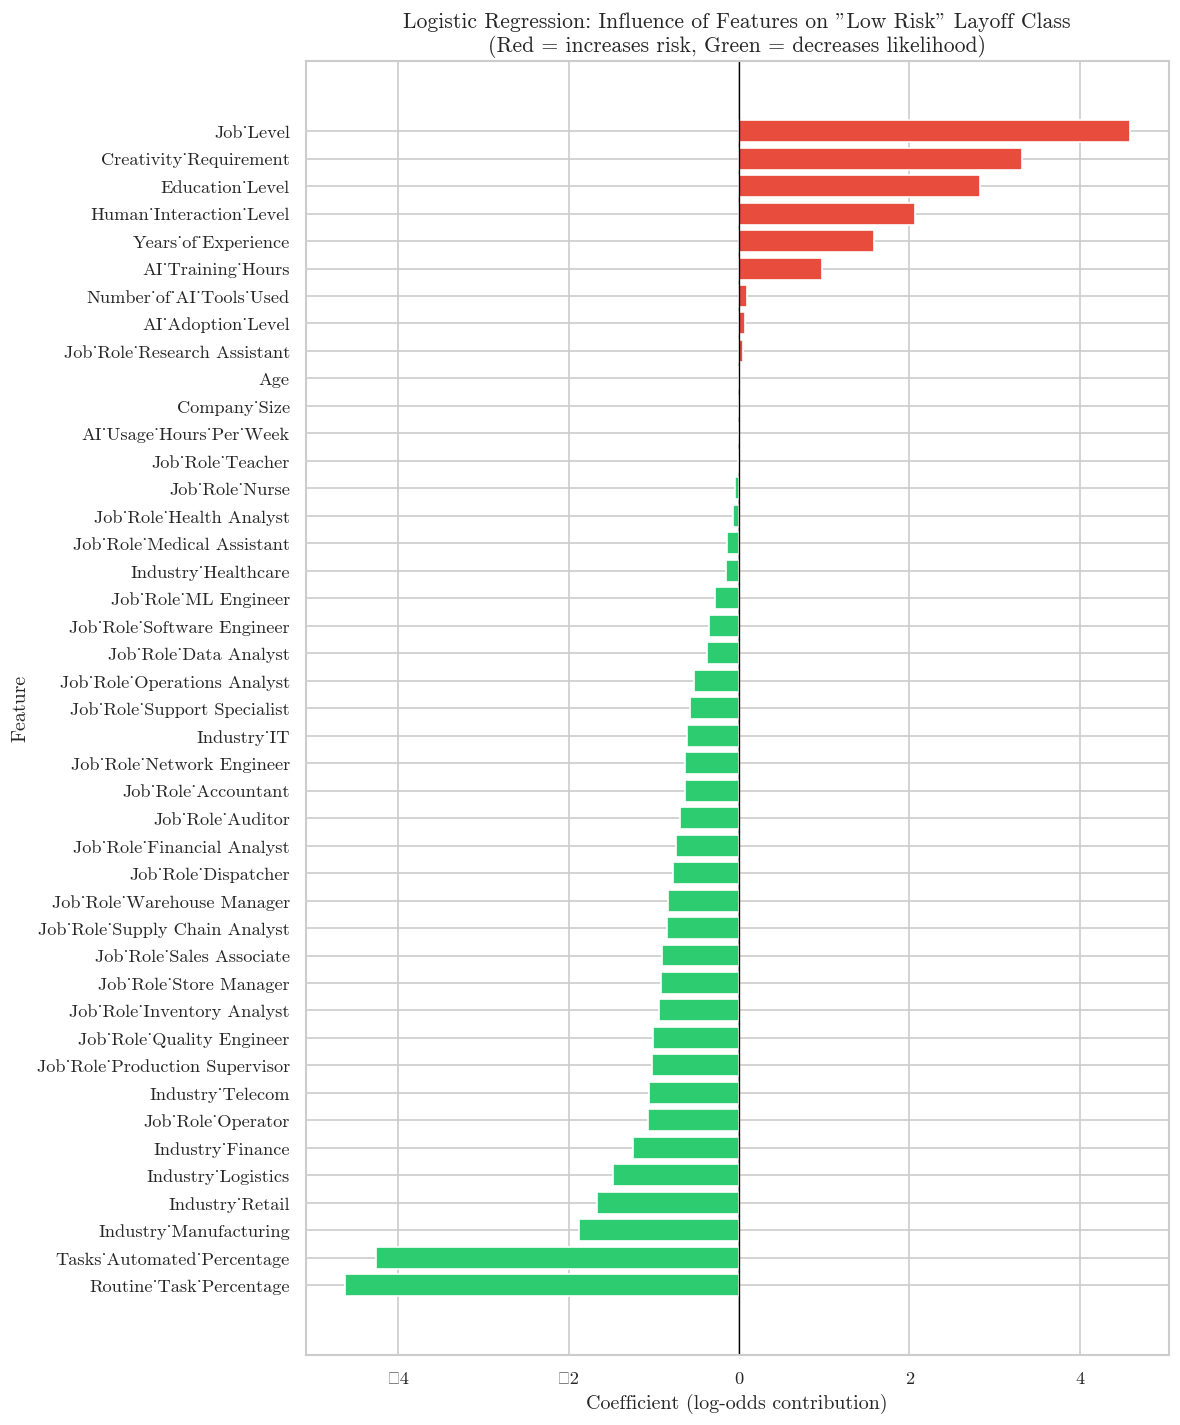

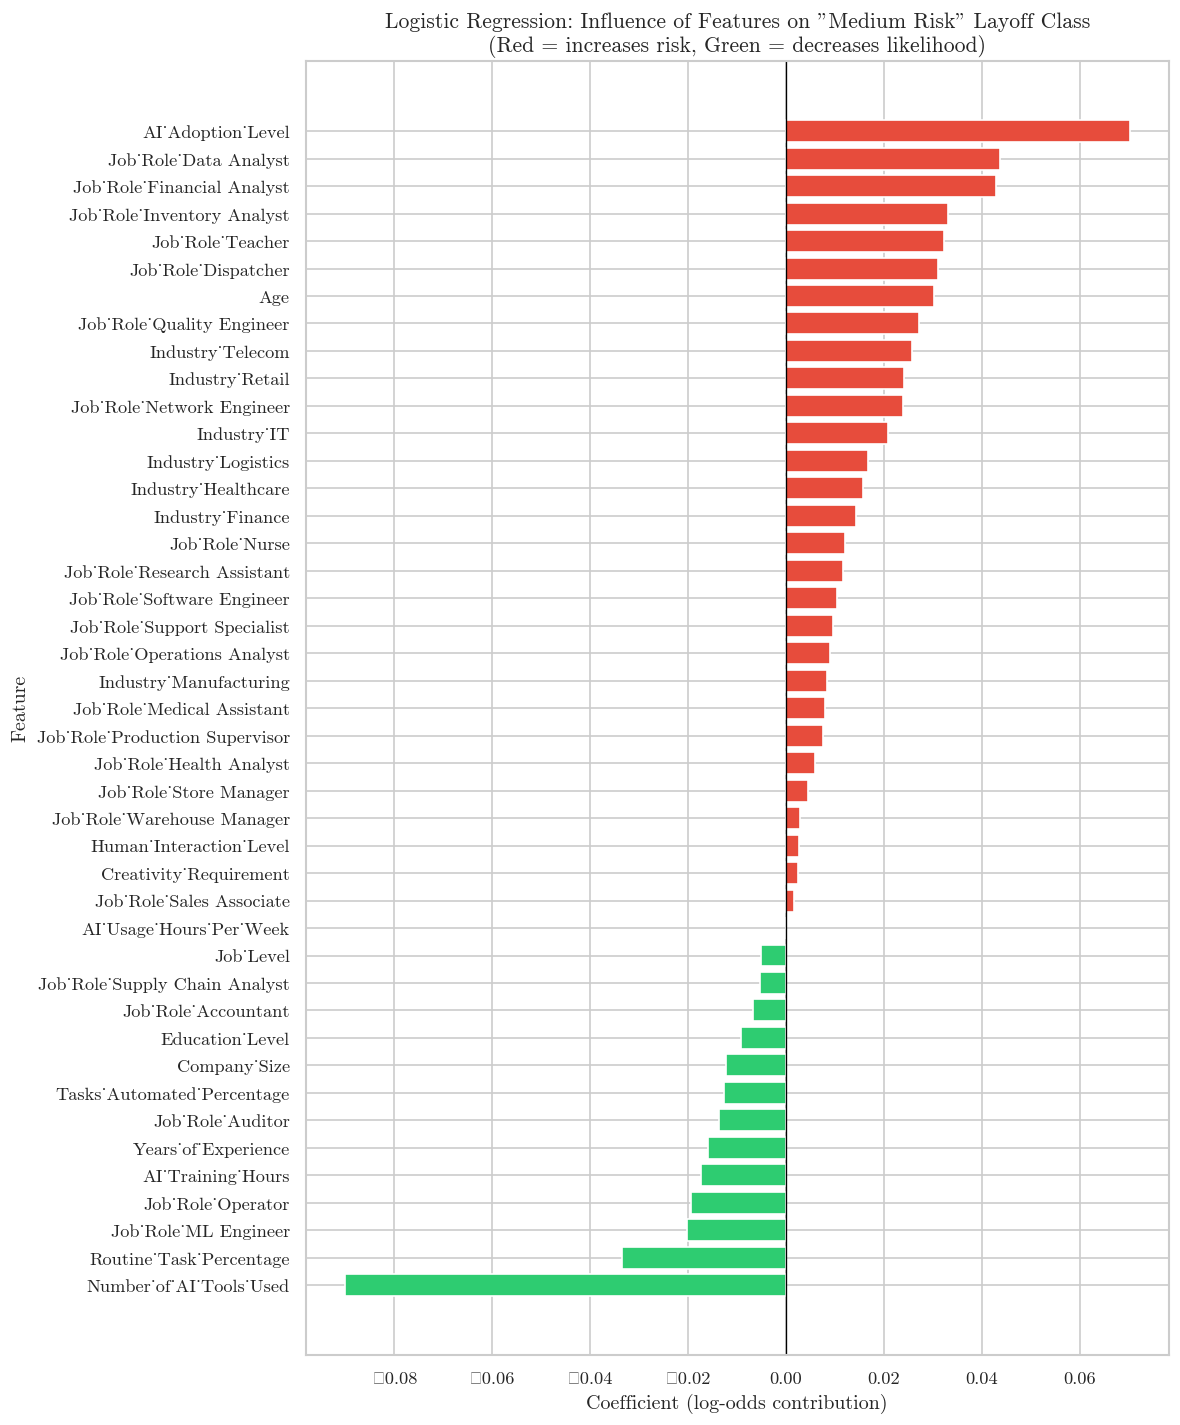

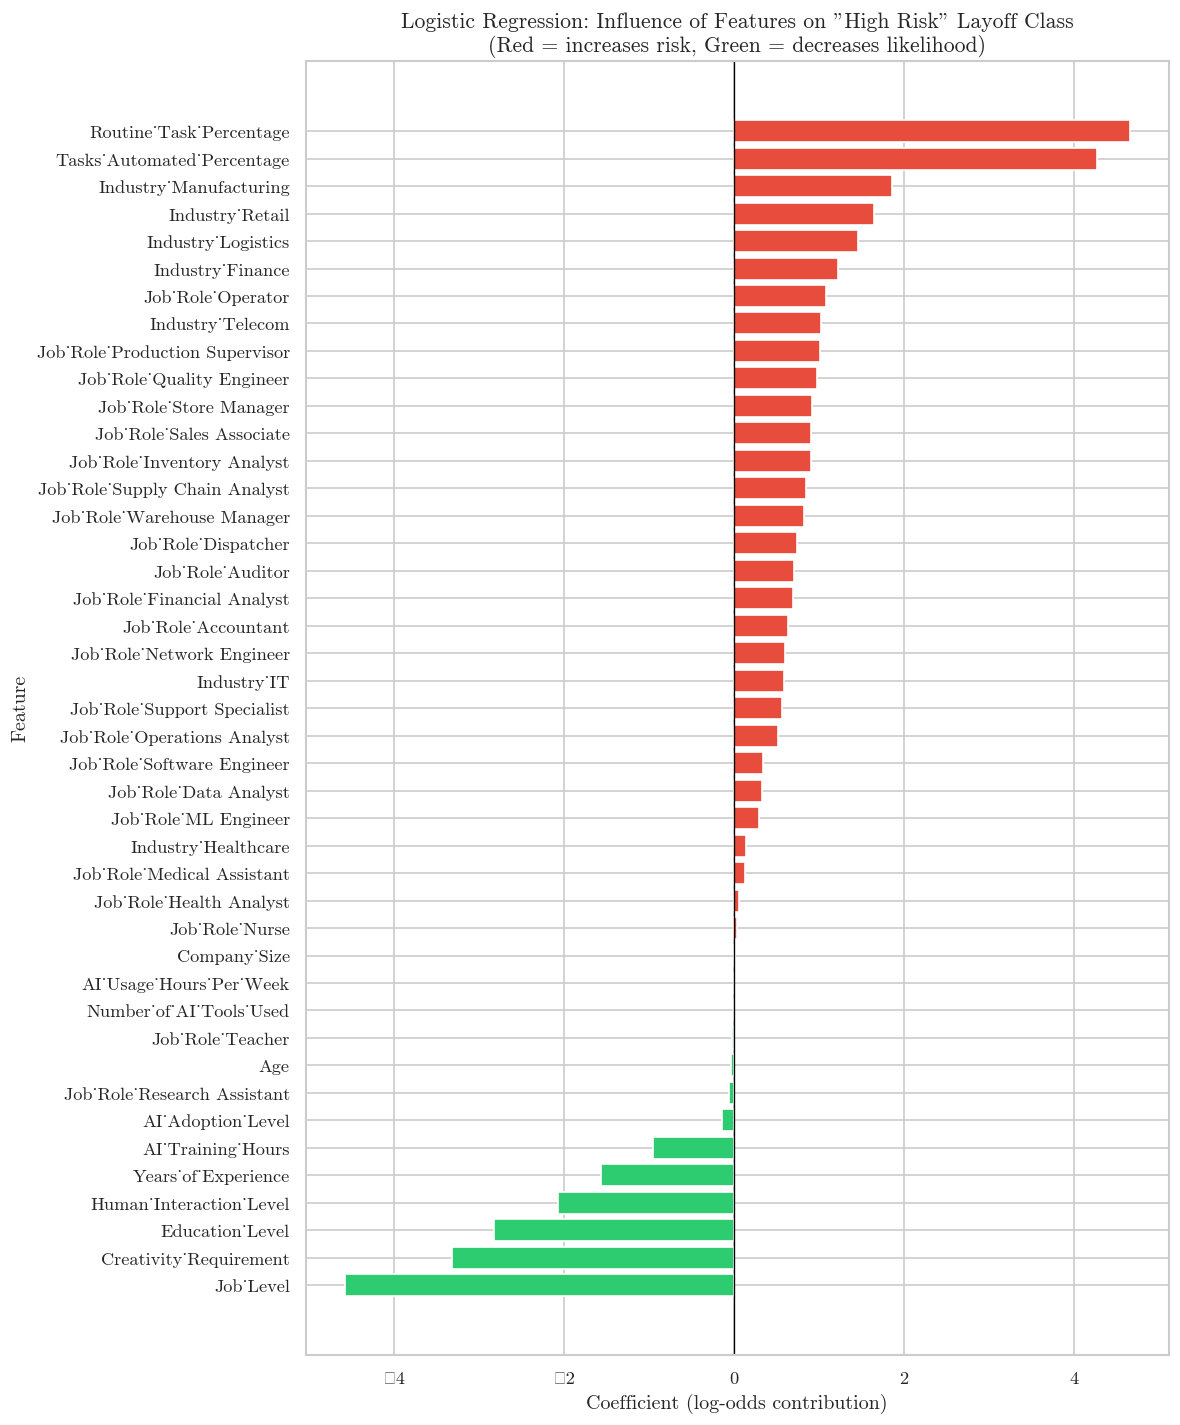

In [97]:
"""
Logistic regression coefficients are per-class log-odds contributions
(multinomial/one-vs-rest depending on solver). Sign matters: positive pushes toward that class, negative away.
"""

feature_names = X.columns.tolist()

coef_df = pd.DataFrame(
    lr_model.coef_.T,
    index=feature_names,
    columns=class_names
)

coef_df['Mean_Abs_Coef'] = coef_df[class_names].abs().mean(axis=1)
coef_df = coef_df.sort_values('Mean_Abs_Coef', ascending=False)

class_names_ordered = ['Low', 'Medium', 'High']

for cls in class_names_ordered:
    sorted_cls = coef_df.sort_values(cls)
    n_features = len(sorted_cls)

    plt.figure(figsize=(10, max(8, n_features * 0.28)))
    colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in sorted_cls[cls]]
    plt.barh(sorted_cls.index, sorted_cls[cls], color=colors, edgecolor='white')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title(f'Logistic Regression: Influence of Features on "{cls} Risk" Layoff Class\n'
              '(Red = increases risk, Green = decreases likelihood)', fontsize=13)
    plt.xlabel('Coefficient (log-odds contribution)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

### Comparison of Generalisation Test

In [98]:
# Overfitting test
train_acc_lr = lr_model.score(X_train_scaled, y_train)
train_acc_rf = best_rf.score(X_train_scaled, y_train)

print('Generalisation Test \n')
print(f'Logistic Regression; \n Train Accuracy: {train_acc_lr:.4f} versus Test Accuracy: {lr_accuracy:.4f}, Gap: {train_acc_lr - lr_accuracy:.4f} \n ')
print(f'Random Forest (Tuned); \n Train Accuracy: {train_acc_rf:.4f} versus Test Accuracy: {best_rf_accuracy:.4f}, Gap: {train_acc_rf - best_rf_accuracy:.4f}')

Generalisation Test 

Logistic Regression; 
 Train Accuracy: 0.9326 versus Test Accuracy: 0.9293, Gap: 0.0033 
 
Random Forest (Tuned); 
 Train Accuracy: 1.0000 versus Test Accuracy: 0.8832, Gap: 0.1168
